In [1]:
!pip install networkx python-louvain

 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 4.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9460 sha256=82b86934f7e128ec7e639e156975a1e660fb055dad978f4b369fe6f1324b2ca9
  Stored in directory: /home/marcelly/.cache/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain


In [ ]:
#--BUILD k-NN GRAPH WITH SelectedClean_nhis2023.csv--#

In [1]:
#Normalize AGEP_A between [0-1]
import pandas as pd
import numpy as np

df = pd.read_csv("SelectedClean_nhis2023.csv")

AGE_COL = "AGEP_A"
#compute min/max 
age_min = float(df[AGE_COL].min())
age_max = float(df[AGE_COL].max())

def add_scaled_age(df_in, age_col=AGE_COL, age_min=age_min, age_max=age_max, out_col=None):
    if out_col is None:
        out_col = f"{age_col}_scaled"
    if pd.isna(age_min) or pd.isna(age_max) or age_max <= age_min:
        df_in[out_col] = 0.0  # degenerate case: avoid divide-by-zero
    else:
        df_in[out_col] = (df_in[age_col] - age_min) / (age_max - age_min)
    return df_in

#create a working copy 
df_scaled_age = add_scaled_age(df.copy(), age_col=AGE_COL, age_min=age_min, age_max=age_max)

print(df_scaled_age.columns.tolist())             
print(df_scaled_age[['AGEP_A','AGEP_A_scaled']].head())




['HISPALLP_A', 'SEX_A', 'AGEP_A', 'ANXEV_A', 'AGEP_A_scaled']
   AGEP_A  AGEP_A_scaled
0      67       0.604938
1      73       0.679012
2      48       0.370370
3      42       0.296296
4      50       0.395062


In [2]:
##Checking for best k 
import numpy as np
import pandas as pd
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csr_matrix, csgraph

def sweep_k_for_knn_age(
    df_scaled: pd.DataFrame,
    scaled_col: str = "AGEP_A_scaled",
    ks = tuple(range(3, 31)),     # k values to try
    target_gcc: float = 0.98,     # target giant component coverage
    dtype=np.float32,
    compute_weights: bool = True,  # Cmpute RBF sigma & mean similarity
    age_col: str | None = "AGEP_A",
    age_min: float | None = None,
    age_max: float | None = None,
    verbose: bool = True,
):

    X = df_scaled[[scaled_col]].to_numpy(dtype=dtype, copy=False)
    n = X.shape[0]
    results = []

    for k in ks:
        k_eff = min(max(1, k), max(1, n-1))  # guard

        # kNN distances (Euclidean in 1D), directed 
        A_dist = kneighbors_graph(
            X, n_neighbors=k_eff, mode="distance",
            metric="euclidean", include_self=False, n_jobs=-1
        ).tocsr().astype(dtype)

        # unweighted, undirected union graph for connectivity stats 
        U = (A_dist + A_dist.T)            # union
        U.data[:] = 1.0                    # binarize
        U = U.tocsr()                      # ensure CSR

        # connected components
        n_comp, labels = csgraph.connected_components(U, directed=False)
        # giant component fraction
        if n_comp > 0:
            _, counts = np.unique(labels, return_counts=True)
            gcc_frac = counts.max() / n
        else:
            gcc_frac = 0.0

        # edges & degree
        undirected_edges = U.nnz // 2
        mean_degree = float(U.sum(axis=1).mean())

        row = {
            "k": k_eff,
            "n_components": n_comp,
            "giant_component_frac": gcc_frac,
            "edges_undirected": undirected_edges,
            "mean_degree": mean_degree,
        }

        # convert distances into RBF weights and summarize
        if compute_weights:
            nz = A_dist.data
            sigma = float(np.median(nz)) if nz.size else 1.0
            W = A_dist.tocsr(copy=True)
            W.data = np.exp(-(W.data**2) / (2.0 * sigma**2 + 1e-12)).astype(dtype)
            W = ((W + W.T) * 0.5).tocsr()  # symmetric
            row.update({
                "sigma_median": sigma,
                "mean_similarity": float(W.data.mean()) if W.nnz else 0.0
            })

        results.append(row)

    df_res = pd.DataFrame(results).sort_values("k").reset_index(drop=True)

    
    # pick the smallest k 
    candidates = df_res[df_res["giant_component_frac"] >= target_gcc]
    if not candidates.empty:
        # keep mean_degree below a soft upper bound (e.g., <= 25)
        soft_cap = candidates[candidates["mean_degree"] <= 25]
        if not soft_cap.empty:
            recommended_k = int(soft_cap.iloc[0]["k"])
        else:
            recommended_k = int(candidates.iloc[0]["k"])
    else:
        # the k with the max giant component fraction; break ties by smaller k
        best_row = df_res.sort_values(
            ["giant_component_frac", "k"], ascending=[False, True]
        ).iloc[0]
        recommended_k = int(best_row["k"])

    sigma_star = None
    if compute_weights and "sigma_median" in df_res.columns:
        sigma_star = float(df_res.loc[df_res["k"] == recommended_k, "sigma_median"].iloc[0])

    # figure out the age bounds for the printout
    used_age_min = age_min
    used_age_max = age_max
    if (used_age_min is None or used_age_max is None) and age_col and (age_col in df_scaled.columns):
        used_age_min = float(df_scaled[age_col].min())
        used_age_max = float(df_scaled[age_col].max())


    if verbose:
        print(f"Recommended k: {recommended_k}")
        if sigma_star is not None:
            print(f"Sigma* (median kNN distance at k={recommended_k}): {sigma_star:.6f}")
        if used_age_min is not None and used_age_max is not None:
            print(f"Age scaling used: min={used_age_min:.3f}, max={used_age_max:.3f}")
        else:
            # fall back to scaled column range (if original min/max not provided)
            smin = float(df_scaled[scaled_col].min())
            smax = float(df_scaled[scaled_col].max())
            print(f"Scaled range for '{scaled_col}': [{smin:.6f}, {smax:.6f}]")

    return df_res, recommended_k


# Ensure df_scaled_age already has AGEP_A_scaled [0,1]
df_metrics, k_star = sweep_k_for_knn_age(
    df_scaled_age,
    scaled_col="AGEP_A_scaled",
    ks=range(5, 31),
    target_gcc=0.98,
    compute_weights=True,
    age_col="AGEP_A",          # so it can print original age bounds
    age_min=float(df_scaled_age["AGEP_A"].min()),  # optional but precise
    age_max=float(df_scaled_age["AGEP_A"].max()),
    verbose=True
)

print(df_metrics.head())
print("Recommended k:", k_star)

Recommended k: 30
Sigma* (median kNN distance at k=30): 0.000000
Age scaling used: min=18.000, max=99.000
   k  n_components  giant_component_frac  edges_undirected  mean_degree  \
0  5         29460              0.000034                 0     0.000000   
1  6         29454              0.000238                 6     0.000407   
2  7         29453              0.000272                12     0.000815   
3  8         29452              0.000305                18     0.001222   
4  9         29451              0.000339                24     0.001629   

   sigma_median  mean_similarity  
0           0.0         0.503590  
1           0.0         0.504176  
2           0.0         0.504766  
3           0.0         0.505359  
4           0.0         0.505954  
Recommended k: 30


In [3]:
#Building k-NN graph based on AGE only

# k-NN graph from AGE only (no protected attrs), RBF similarity on age
import json
import numpy as np
from sklearn.neighbors import kneighbors_graph #memory-efficient k-NN graph builder
from scipy import sparse

def build_knn_from_pre_scaled(
    df_scaled, scaled_col="AGEP_A_scaled",
    k=30, #number of nearest neighbors per node ( Recommended k)
    sigma=None, #width of the RBF/Gaussian kernel estimated from data
    mutual=False, #keep neighbors based on union (average the two directions).
    save_prefix="A_graph_age_rbf",  # name of output graph
    dtype=np.float32,# saving memory
    sigma_floor=1e-4  # small lower bound in scaled-age units
):
    X = df_scaled[[scaled_col]].to_numpy(dtype=dtype, copy=False) # array containing only pre-scaled age without unnecessary copies
    n = X.shape[0] # number of nodes
    if k >= n:
        k = max(1, n-1)

    # kNN distances in 1D (Euclidean)
    A_dist = kneighbors_graph(
        X, n_neighbors=k, mode="distance", # edge values are distances
        metric="euclidean", 
        include_self=False, n_jobs=-1 # avoids self-loops and sppedup with all CPU cores
    ).tocsr().astype(dtype) 

    # choose sigma based on estimate of the median of the non-zero neighbor distances
    if sigma is None:
        nz = A_dist.data
        pos = nz[nz > 0]  # ignore same-age zeros
        if pos.size:
            sigma = float(np.median(pos))
        else:
            # all neighbors at zero distance → pick a small but usable sigma
            sigma = 0.01
    sigma = max(float(sigma), sigma_floor)

    # distance -> RBF similarity, then symmetrize
    A_sim = A_dist.tocsr(copy=True)
    A_sim.data = np.exp(-(A_sim.data**2) / (2.0 * sigma**2 + 1e-12)).astype(dtype) # prevents division by zero if sigma is tiny
    A_sim = ((A_sim + A_sim.T) * 0.5).tocsr() #include edges appearing in either direction and average of the two weights

    # save outputs + minimal params (no age min/max needed because you pre-scaled)
    sparse.save_npz(f"{save_prefix}.npz", A_sim)
    params = {
        "scaled_col": scaled_col,
        "k": int(k),
        "sigma": float(sigma),
        "dtype": "float32",
        "mutual": bool(mutual),
        "similarity": "rbf_on_euclidean_age (pre-scaled)"
    }
    with open(f"{save_prefix}_params.json", "w") as f:
        json.dump(params, f, indent=2)

    print(f"Saved graph: {save_prefix}.npz  (nodes={n}, edges={A_sim.nnz//2} undirected approx.)")
    print(f"Saved params: {save_prefix}_params.json  (k={k}, sigma={sigma:.6f})")
    return A_sim, params
 
A_sim, params = build_knn_from_pre_scaled(
    df_scaled_age,
    scaled_col="AGEP_A_scaled",
    k=30,            
    sigma=None,      
    mutual=False,
    save_prefix="A_graph_age_rbf"
)


Saved graph: A_graph_age_rbf.npz  (nodes=29460, edges=851700 undirected approx.)
Saved params: A_graph_age_rbf_params.json  (k=30, sigma=0.024691)


In [4]:
print("Final sigma used:", params["sigma"])
print("Mean edge similarity:", float(A_sim.data.mean()) if A_sim.nnz else 0.0)

Final sigma used: 0.024691343307495117
Mean edge similarity: 0.5188099145889282


In [7]:
# Community detection with Leiden + summary table

import numpy as np
import pandas as pd
from scipy import sparse
import igraph as ig
import leidenalg as la

# Load graph + node table
A = sparse.load_npz("A_graph_age_rbf.npz").tocsr()

df_nodes = df_scaled_age.reset_index(drop=True).copy()


assert A.shape[0] == len(df_nodes), "Row count mismatch between A and df_nodes."

# Apply binarization mappings (adds new columns)
map_anx  = {'Yes': 1, 'No': 0}
map_sex  = {'Male': 0, 'Female': 1}
map_hisp = {
    'Non-Hispanic White only': 1,
    'Hispanic': 0,
    'Non-Hispanic Black/African American only': 0,
    'Non-Hispanic Asian only': 0,
    'Non-Hispanic AIAN only': 0,
    'Non-Hispanic AIAN and any other group': 0,
    'Multiple races': 0
}

df_nodes["ANXEV_A_bin"]  = df_nodes["ANXEV_A"].map(map_anx).astype(int)       # 1=Yes, 0=No
df_nodes["SEX_A_bin"]    = df_nodes["SEX_A"].map(map_sex).astype(int)         # 1=Female, 0=Male
df_nodes["HISPALLP_BIN"] = df_nodes["HISPALLP_A"].map(map_hisp).astype(int)   # 1=Non-Hisp White only, 0=Hisp+others

# Leiden community detection (RBConfiguration/CPM) 
def csr_to_igraph(A_csr):
    coo = A_csr.tocoo()
    g = ig.Graph(
        n=A_csr.shape[0],
        edges=list(zip(coo.row.tolist(), coo.col.tolist())),
        directed=False
    )
    g.es["weight"] = coo.data.tolist()
    return g

gamma = 1.0  # resolution; increase -> more/smaller communities, decrease -> fewer/larger
g = csr_to_igraph(A)
part = la.find_partition(
    g, la.RBConfigurationVertexPartition,
    weights="weight",
    resolution_parameter=gamma,
    seed=42
)
membership = np.array(part.membership, dtype=int)
quality = float(part.quality())
print(f"Leiden: detected {membership.max()+1} communities (gamma={gamma}), quality={quality:.4f}")

df_nodes["community"] = membership

# Build community summary table
# Label vector (1=Yes diagnosis)
y = df_nodes["ANXEV_A_bin"].to_numpy(int)

# Base summary: size, age stats, outcome rate
summary = (df_nodes
           .assign(y=y)
           .groupby("community", as_index=True)
           .agg(
               size=("community", "size"),
               age_mean=("AGEP_A", "mean"),
               age_std=("AGEP_A", "std"),
               pos_rate=("y", "mean")     # P(ANXEV_A=1)
           ))

# Composition by SEX_A (proportions)
sex_counts = (df_nodes
              .pivot_table(index="community", columns="SEX_A_bin",
                           values="AGEP_A", aggfunc="count", fill_value=0))
sex_props = sex_counts.div(sex_counts.sum(axis=1), axis=0)
sex_props = sex_props.rename(columns={0: "p_male", 1: "p_female"})

# Composition by HISPALLP_BIN (proportions)
h_counts = (df_nodes
            .pivot_table(index="community", columns="HISPALLP_BIN",
                         values="AGEP_A", aggfunc="count", fill_value=0))
h_props = h_counts.div(h_counts.sum(axis=1), axis=0)
h_props = h_props.rename(columns={0: "p_hisp_plus_others", 1: "p_non_hisp_white"})

# Join all parts and sort by size
summary = (summary
           .join(sex_props, how="left")
           .join(h_props,  how="left")
           .sort_values("size", ascending=False))

# Round and show top 10 communities
print("\nCommunity summary (top 10 by size):")
print(summary.head(10).round(3))

#print global baselines for context
print("\nGlobal baselines:")
print(f"  P(ANXEV_A=1):            {df_nodes['ANXEV_A_bin'].mean():.3f}")
print(f"  % Female:                {df_nodes['SEX_A_bin'].mean():.3f}")
print(f"  % Non-Hispanic White:    {df_nodes['HISPALLP_BIN'].mean():.3f}")


Leiden: detected 69 communities (gamma=1.0), quality=1739181.5155

Community summary (top 10 by size):
           size  age_mean  age_std  pos_rate  p_male  p_female  \
community                                                        
0          1111      85.0      0.0     0.089   0.350     0.650   
1           612      67.0      0.0     0.157   0.441     0.559   
2           593      65.0      0.0     0.137   0.504     0.496   
3           592      68.0      0.0     0.152   0.448     0.552   
4           563      70.0      0.0     0.169   0.449     0.551   
5           560      63.0      0.0     0.175   0.445     0.555   
6           552      66.0      0.0     0.158   0.491     0.509   
7           551      62.0      0.0     0.194   0.457     0.543   
8           537      72.0      0.0     0.130   0.467     0.533   
9           534      64.0      0.0     0.182   0.455     0.545   

           p_hisp_plus_others  p_non_hisp_white  
community                                        
0   

In [8]:
#checking if scaled_age was used as parameter for create the communities
import json
with open("A_graph_age_rbf_params.json") as f:
    params = json.load(f)
print(params)

{'scaled_col': 'AGEP_A_scaled', 'k': 30, 'sigma': 0.024691343307495117, 'dtype': 'float32', 'mutual': False, 'similarity': 'rbf_on_euclidean_age (pre-scaled)'}


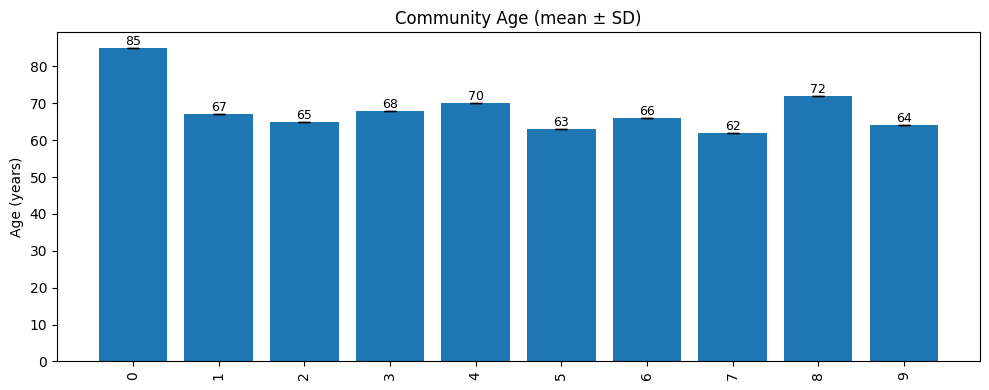

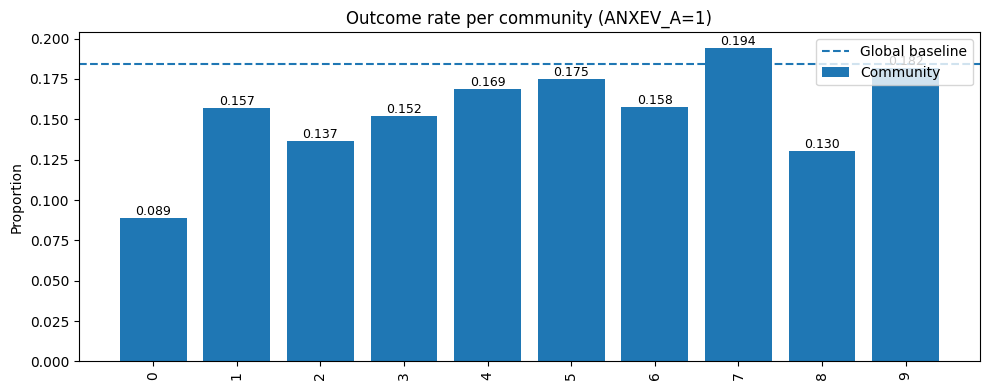

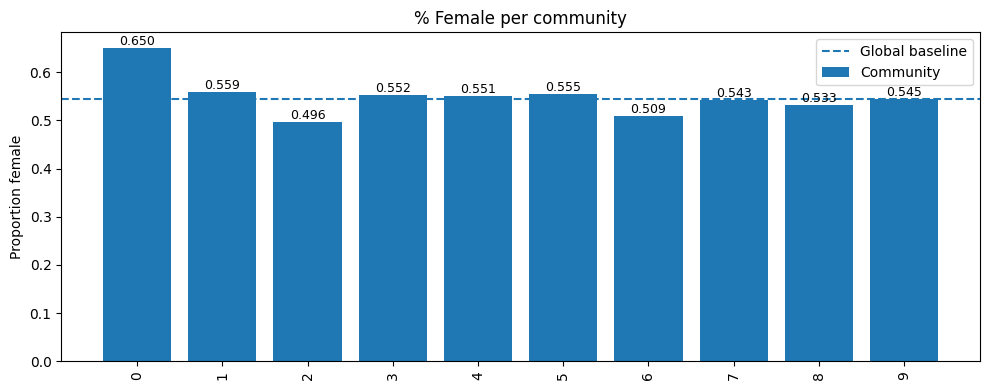

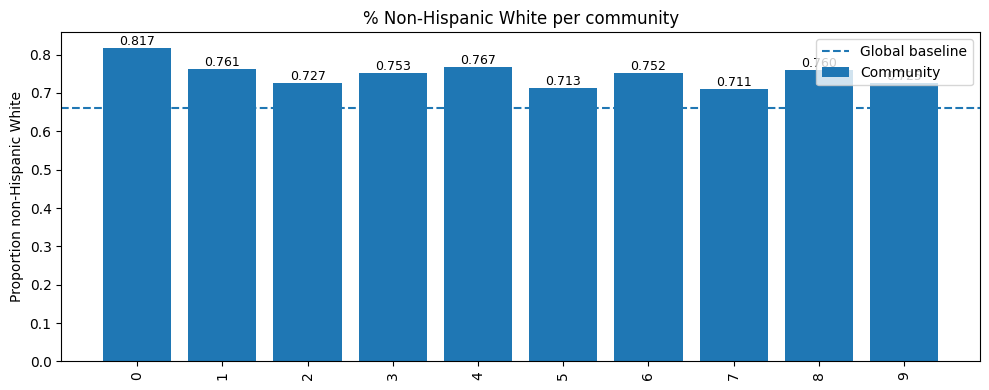

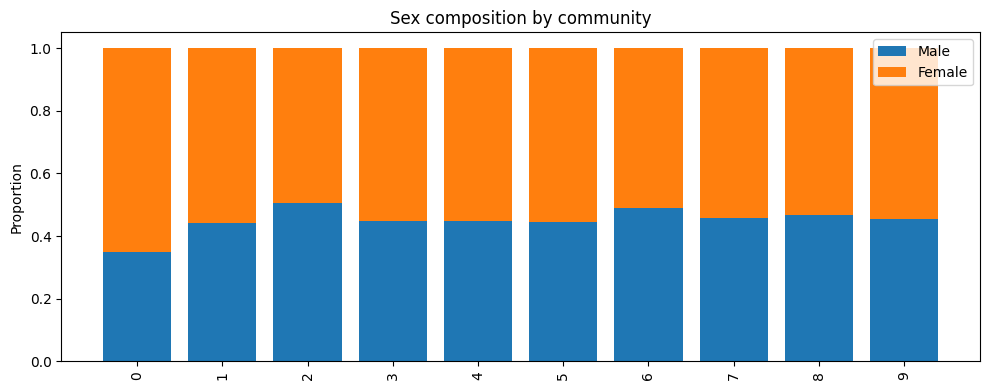

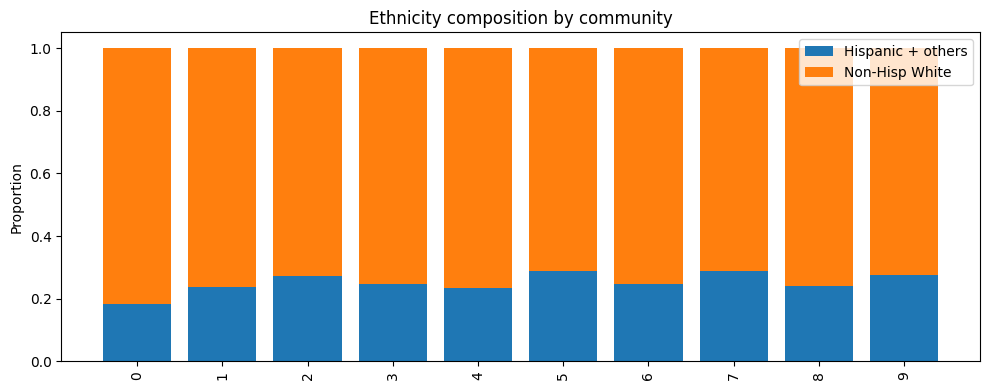

In [9]:
#Visualizing results in graphs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pick the top N communities by size 
TOPN = 10
top = summary.head(TOPN).reset_index() 
labels = top["community"].astype(int).astype(str).tolist()
x = np.arange(len(top))

# global baselines
g_pos    = df_nodes["ANXEV_A_bin"].mean()
g_female = df_nodes["SEX_A_bin"].mean()
g_nhw    = df_nodes["HISPALLP_BIN"].mean()  # 1 = Non-Hispanic White only

# 1) Age mean ± SD
fig1, ax1 = plt.subplots(figsize=(10,4))
bars = ax1.bar(x, top["age_mean"].values, yerr=top["age_std"].values, capsize=4)
ax1.set_title("Community Age (mean ± SD)")
ax1.set_ylabel("Age (years)")
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=90)
for i, v in enumerate(top["age_mean"].values):
    ax1.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

#Outcome rate P(ANXEV_A=1) per community vs global
fig2, ax2 = plt.subplots(figsize=(10,4))
ax2.bar(x, top["pos_rate"].values)
ax2.axhline(g_pos, linestyle="--")
ax2.set_title("Outcome rate per community (ANXEV_A=1)")
ax2.set_ylabel("Proportion")
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=90)

# annotate bars
for i, v in enumerate(top["pos_rate"].values):
    ax2.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax2.legend(["Global baseline", "Community"], loc="upper right")
plt.tight_layout()
plt.show()

#  % Female per community vs global
fig3, ax3 = plt.subplots(figsize=(10,4))
ax3.bar(x, top["p_female"].values)
ax3.axhline(g_female, linestyle="--")
ax3.set_title("% Female per community")
ax3.set_ylabel("Proportion female")
ax3.set_xticks(x); ax3.set_xticklabels(labels, rotation=90)
for i, v in enumerate(top["p_female"].values):
    ax3.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax3.legend(["Global baseline", "Community"], loc="upper right")
plt.tight_layout()
plt.show()

# % Non-Hispanic White per community vs global
fig4, ax4 = plt.subplots(figsize=(10,4))
ax4.bar(x, top["p_non_hisp_white"].values)
ax4.axhline(g_nhw, linestyle="--")
ax4.set_title("% Non-Hispanic White per community")
ax4.set_ylabel("Proportion non-Hispanic White")
ax4.set_xticks(x); ax4.set_xticklabels(labels, rotation=90)
for i, v in enumerate(top["p_non_hisp_white"].values):
    ax4.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax4.legend(["Global baseline", "Community"], loc="upper right")
plt.tight_layout()
plt.show()

# Stacked composition bars for Sex and Ethnicity
# Sex composition (Male/Female)
fig5, ax5 = plt.subplots(figsize=(10,4))
male = top["p_male"].values
female = top["p_female"].values
ax5.bar(x, male, label="Male")
ax5.bar(x, female, bottom=male, label="Female")
ax5.set_title("Sex composition by community")
ax5.set_ylabel("Proportion")
ax5.set_xticks(x); ax5.set_xticklabels(labels, rotation=90)
ax5.legend()
plt.tight_layout()

plt.show()

# Ethnicity composition (Hisp+others vs Non-Hisp White)
fig6, ax6 = plt.subplots(figsize=(10,4))
hisp_plus = top["p_hisp_plus_others"].values
nhw = top["p_non_hisp_white"].values
ax6.bar(x, hisp_plus, label="Hispanic + others")
ax6.bar(x, nhw, bottom=hisp_plus, label="Non-Hisp White")
ax6.set_title("Ethnicity composition by community")
ax6.set_ylabel("Proportion")
ax6.set_xticks(x); ax6.set_xticklabels(labels, rotation=90)
ax6.legend()
plt.tight_layout()
plt.show()


In [28]:
#Checking for structural bias (Homophily)

import numpy as np
from scipy import sparse

A = A.tocsr().astype(np.float64)
A.setdiag(0); A.eliminate_zeros() # remove self-loops & zero entries
if (A - A.T).nnz != 0:         # ensure symmetry
    A = ((A + A.T) * 0.5).tocsr()

def norm(s): 
    return s.astype(str).str.strip().str.lower()

g_sex  = (norm(df_nodes["SEX_A"]) == "female").to_numpy(dtype=int)                 # 0=Male, 1=Female
g_hisp = (norm(df_nodes["HISPALLP_A"]) == "non-hispanic white only").to_numpy(dtype=int)  # 0=Hisp+others, 1=NH White

def weighted_homophily(A, group):
    coo = A.tocoo()  # fast edge-wise access
    same = (group[coo.row] == group[coo.col]).astype(np.float32)
    # numerator = sum of weights where endpoints share the same group
    num = float((same * coo.data).sum())
    den = float(coo.data.sum()) + 1e-12
    return num / den

def expected_same_prob(group):
    counts = np.bincount(group)     # how many 0s and 1s
    p = counts / counts.sum()       # group proportions
    return float((p**2).sum())      # sum_g p_g^2

def degree_parity(A, group):
    deg = np.asarray(A.sum(1)).ravel()  # weighted degree per node
    return float(deg[group==0].mean()), float(deg[group==1].mean())

def neighbor_same_group_exposure(A, group):
    # deg[i] = total incident weight on node i
    deg = (np.asarray(A.sum(1)).ravel() + 1e-12)

    # frac_one[i] = fraction of i’s edge weight that goes to group==1
    frac_one = np.asarray(A.dot(group)) / deg

    # same-group exposure:
    # if node i is in group 1 -> same = frac_one[i]
    # if node i is in group 0 -> same = 1 - frac_one[i]
    same_exp = np.where(group == 1, frac_one, 1.0 - frac_one)

    # average per group
    return float(same_exp[group==0].mean()), float(same_exp[group==1].mean())

def print_structural_summary(name, g, labels):
    h_obs = weighted_homophily(A, g)
    h_exp = expected_same_prob(g)
    d0, d1 = degree_parity(A, g)
    e0, e1 = neighbor_same_group_exposure(A, g)
    print(f"{name}: homophily obs={h_obs:.3f} exp={h_exp:.3f} Δ={h_obs-h_exp:+.3f}")
    print(f"  mean degree: {labels[0]}={d0:.2f}, {labels[1]}={d1:.2f}")
    print(f"  same-group exposure: {labels[0]}={e0:.3f}, {labels[1]}={e1:.3f}")

print_structural_summary("SEX",  g_sex,  {0:"Male", 1:"Female"})
print_structural_summary("HISP", g_hisp, {0:"Hisp+Others", 1:"Non-Hisp White"})


SEX: homophily obs=0.524 exp=0.504 Δ=+0.021
  mean degree: Male=21.63, Female=21.26
  same-group exposure: Male=0.482, Female=0.560
HISP: homophily obs=0.625 exp=0.556 Δ=+0.068
  mean degree: Hisp+Others=19.10, Non-Hisp White=22.59
  same-group exposure: Hisp+Others=0.442, Non-Hisp White=0.719


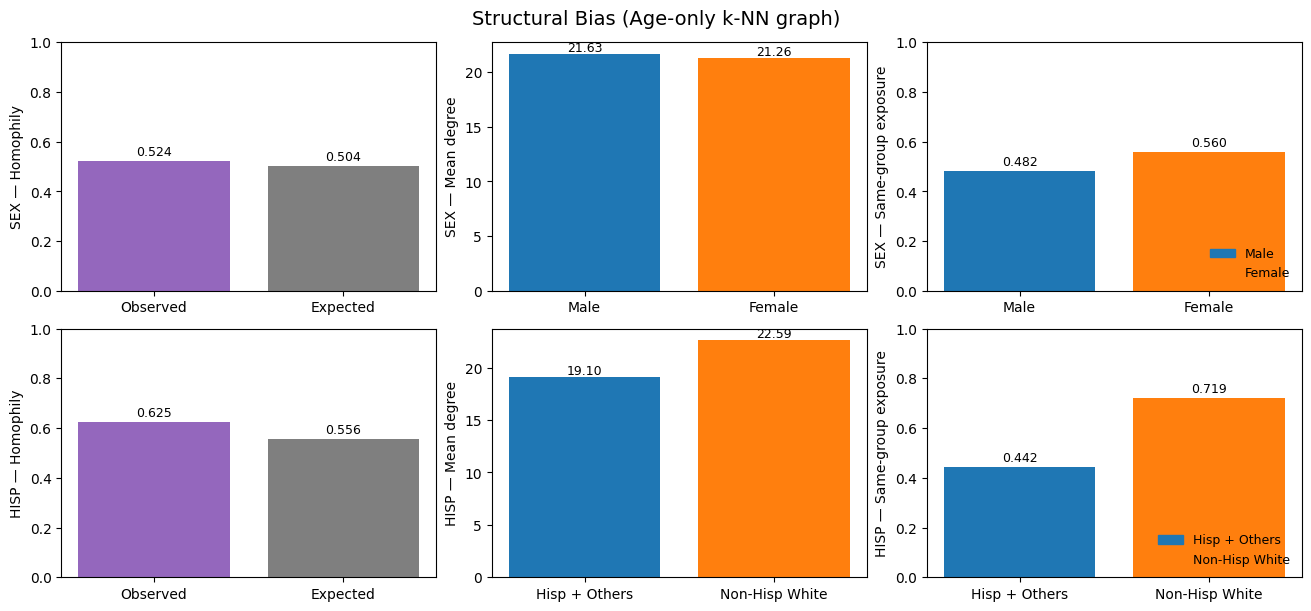

In [34]:
#Visualizing homophily in graphs

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def weighted_homophily(A, group):
    coo = A.tocoo()
    same = (group[coo.row] == group[coo.col]).astype(np.float64)
    num = float((same * coo.data).sum())
    den = float(coo.data.sum()) + 1e-12
    return num / den

def expected_same_prob(group):
    counts = np.bincount(group, minlength=2).astype(np.float64)
    p = counts / counts.sum()
    return float((p**2).sum())

def degree_parity(A, group):
    deg = np.asarray(A.sum(1)).ravel()
    return float(deg[group==0].mean()), float(deg[group==1].mean())

def neighbor_same_group_exposure(A, group):
    deg = (np.asarray(A.sum(1)).ravel() + 1e-12)
    frac_one = np.asarray(A.dot(group)) / deg           # share of weight to group==1
    same_exp = np.where(group == 1, frac_one, 1.0 - frac_one)
    return float(same_exp[group==0].mean()), float(same_exp[group==1].mean())

def _annotate_bars(ax, fmt="{:.3f}", dy=0.0):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.text(p.get_x() + p.get_width()/2, h + dy, fmt.format(h),
                    ha='center', va='bottom', fontsize=9)


def plot_structural_bias_dashboard_labeled(
    A, g_sex, g_hisp,
    sex_labels=("Male","Female"),
    hisp_labels=("Hisp + Others","Non-Hisp White"),
    sex_colors=("tab:blue", "tab:orange"),
    hisp_colors=("tab:blue", "tab:orange"),
    homophily_colors=("tab:purple", "tab:gray"),
    title="Graph Structural Bias Dashboard"
):
    # compute metrics for SEX and HISP
    metrics = {}
    for name, g in [("SEX", g_sex), ("HISP", g_hisp)]:
        h_obs = weighted_homophily(A, g)
        h_exp = expected_same_prob(g)
        d0, d1 = degree_parity(A, g)
        e0, e1 = neighbor_same_group_exposure(A, g)
        metrics[name] = {"h_obs":h_obs, "h_exp":h_exp, "d0":d0, "d1":d1, "e0":e0, "e1":e1}

    label_map = {"SEX": sex_labels, "HISP": hisp_labels}
    color_map   = {"SEX": sex_colors,   "HISP": hisp_colors}

    fig, axes = plt.subplots(2, 3, figsize=(13, 6), constrained_layout=True)

    for r, attr in enumerate(["SEX", "HISP"]):
        m = metrics[attr]
        (lbl0, lbl1) = label_map[attr]
        (c0, c1)     = color_map[attr]
        
        # (col 0) Homophily: observed vs expected
        ax = axes[r, 0]
        ax.bar(["Observed", "Expected"], [m["h_obs"], m["h_exp"]],
               color=homophily_colors)
        ax.set_ylim(0, 1)
        ax.set_ylabel(f"{attr} — Homophily")
        _annotate_bars(ax, "{:.3f}", dy=0.01)

        # (col 1) Mean degree: group 0 vs group 1
        ax = axes[r, 1]
        ax.bar([lbl0, lbl1], [m["d0"], m["d1"]], color=[c0, c1])
        ax.set_ylabel(f"{attr} — Mean degree")
        _annotate_bars(ax, "{:.2f}", dy=0.01)

        # (col 2) Same-group exposure: group 0 vs group 1
        ax = axes[r, 2]
        ax.bar([lbl0, lbl1], [m["e0"], m["e1"]], color=[c0, c1])
        ax.set_ylim(0, 1)
        ax.set_ylabel(f"{attr} — Same-group exposure")
        _annotate_bars(ax, "{:.3f}", dy=0.01)

        legend_patches = [Patch(color=c0, label=lbl0), Patch(color=c1, label=lbl1)]
        axes[r, 2].legend(handles=legend_patches, loc="lower right", frameon=False, fontsize=9)

    fig.suptitle(title, fontsize=14)
    plt.show()



plot_structural_bias_dashboard_labeled(
    A, g_sex, g_hisp,
    sex_labels=("Male","Female"),
    hisp_labels=("Hisp + Others","Non-Hisp White"),
    sex_colors=("tab:blue","tab:orange"),
    hisp_colors=("tab:blue", "tab:orange"),
    homophily_colors=("tab:purple","tab:gray"),
    title="Structural Bias (Age-only k-NN graph)"
)


In [ ]:
#--BUILD k-NN GRAPH WITH reweighed_intersectional_with_age.csv--#

In [7]:
#Checking for best k 

import numpy as np
import pandas as pd
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csr_matrix, csgraph
import matplotlib.pyplot as plt


def sweep_k_for_knn_age_weighted(
    df_scaled: pd.DataFrame,
    *,
    scaled_col: str = "AGEP_A_scaled",
    weight_col: str = "instance_weight",
    ks=tuple(range(3, 31)),
    target_gcc: float = 0.98,       # target *weighted* GCC coverage
    dtype=np.float32,
    compute_weights: bool = True,   # also compute RBF sigma & mean similarity
    age_col: str | None = "AGEP_A",
    age_min: float | None = None,
    age_max: float | None = None,
    verbose: bool = True,
    mean_degree_cap: float = 25.0,  # soft cap to avoid overly dense graphs
):
   # feature matrix: just the (n x 1) age-scaled column
    X = df_scaled[[scaled_col]].to_numpy(dtype=dtype, copy=False)
    n = X.shape[0]

   #weights: use instance_weight 
    if weight_col in df_scaled.columns:
        weights = pd.to_numeric(df_scaled[weight_col], errors="coerce").to_numpy(dtype=np.float32)
        
        # Replace NaN/negatives with 0; typical survey weights should be > 0
        weights = np.where(np.isfinite(weights) & (weights > 0.0), weights, 0.0)
    else:
        # Fallback to uniform weights if missing 
        weights = np.ones(n, dtype=np.float64)

    total_weight = float(weights.sum())
    if total_weight <= 0.0:
        # Guard: if all weights are zero, weighted coverage is meaningless
        total_weight = 1.0
    
    results = []

    for k in ks:
        k_eff = min(max(1, k), max(1, n-1)) # clamp to [1, n-1]

        # # Directed kNN graph with distances (Euclidian)
        A_dist = kneighbors_graph(
            X, n_neighbors=k_eff, mode="distance",
            metric="euclidean", include_self=False, n_jobs=-1
        ).tocsr().astype(dtype)

        # unweighted, undirected union graph for connectivity stats 
        U = (A_dist + A_dist.T)            # union
        U.data[:] = 1.0                    # binarize
        U = U.tocsr()                      # ensure CSR

        # connected components
        n_comp, labels = csgraph.connected_components(U, directed=False)
        
        # Unweighted giant component (GCC) fraction
        if n_comp > 0:
            _, counts = np.unique(labels, return_counts=True)
            gcc_frac = counts.max() / n
        else:
            gcc_frac = 0.0


         # Weighted GCC fraction
        if n_comp > 0:
            # Sum weights per component (labels are 0..n_comp-1)
            comp_weight = np.bincount(labels, weights=weights, minlength=n_comp)
            gcc_weight_frac = float(comp_weight.max() / total_weight)
        else:
            gcc_weight_frac = 0.0

        # edges & degree
        undirected_edges = U.nnz // 2
        mean_degree = float(U.sum(axis=1).mean())

        row = {
            "k": k_eff,
            "n_components": n_comp,
            "giant_component_frac": gcc_frac,
            "giant_component_weight_frac": float(gcc_weight_frac),# weighted (selection criterion)
            "edges_undirected": undirected_edges,
            "mean_degree": mean_degree,
        }

        # convert distances into RBF weights and summarize
        if compute_weights:
            nz = A_dist.data
            sigma = float(np.median(nz)) if nz.size else 1.0
            W = A_dist.tocsr(copy=True)
             # Gaussian kernel on distances
            W.data = np.exp(-(W.data**2) / (2.0 * sigma**2 + 1e-12)).astype(dtype)
            W = ((W + W.T) * 0.5).tocsr()  # symmetric
            row.update({
                "sigma_median": sigma,
                "mean_similarity": float(W.data.mean()) if W.nnz else 0.0
            })

        results.append(row)

    df_res = pd.DataFrame(results).sort_values("k").reset_index(drop=True)

    # Select k using *weighted* GCC criterion
    crit = "giant_component_weight_frac"
    candidates = df_res[df_res[crit] >= target_gcc]
    if not candidates.empty:
        soft = candidates[candidates["mean_degree"] <= mean_degree_cap]
        pick_from = soft if not soft.empty else candidates
        recommended_k = int(pick_from.iloc[0]["k"])  # smallest k wins due to sort
    else:
        # No k reaches the target -> pick the one with the largest *weighted* GCC;
        # break ties by smaller k.
        best_row = df_res.sort_values([crit, "k"], ascending=[False, True]).iloc[0]
        recommended_k = int(best_row["k"])

    # Look up sigma* for the chosen k 
    sigma_star = None
    if compute_weights and "sigma_median" in df_res.columns:
        sigma_star = float(df_res.loc[df_res["k"] == recommended_k, "sigma_median"].iloc[0])

    # Pretty age bounds for logging
    used_age_min = age_min
    used_age_max = age_max
    if (used_age_min is None or used_age_max is None) and age_col and (age_col in df_scaled.columns):
        used_age_min = float(df_scaled[age_col].min())
        used_age_max = float(df_scaled[age_col].max())

    if verbose:
        print(f"Recommended k (by WEIGHTED GCC ≥ {target_gcc:.2%}): {recommended_k}")
        if sigma_star is not None:
            print(f"Sigma* (median kNN distance at k={recommended_k}): {sigma_star:.6f}")
        # Report both unweighted and weighted coverage at k*
        at_k = df_res[df_res["k"] == recommended_k].iloc[0]
        print(f"At k={recommended_k}: GCC (unweighted) = {at_k['giant_component_frac']:.3f}, "
              f"GCC (weighted) = {at_k['giant_component_weight_frac']:.3f}")
        if used_age_min is not None and used_age_max is not None:
            print(f"Age scaling used: min={used_age_min:.3f}, max={used_age_max:.3f}")
        else:
            smin = float(df_scaled[scaled_col].min())
            smax = float(df_scaled[scaled_col].max())
            print(f"Scaled range for '{scaled_col}': [{smin:.6f}, {smax:.6f}]")

    return df_res, recommended_k



if __name__ == "__main__":
    
    # Load as-is (you said the needed columns are present with no missing ages)
    df = pd.read_csv("reweighed_intersectional_with_age.csv")

    # ensure numeric dtypes for safety (won't drop rows)
    for c in ["AGEP_A", "AGEP_A_scaled", "instance_weight"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df_scaled_age = df 

    # Run the sweep
    df_metrics, k_star = sweep_k_for_knn_age_weighted(
        df_scaled_age,
        scaled_col="AGEP_A_scaled",
        weight_col="instance_weight",
        ks=range(5, 31),
        target_gcc=0.98,
        compute_weights=True,
        age_col="AGEP_A",
        age_min=float(df["AGEP_A"].min()),
        age_max=float(df["AGEP_A"].max()),
        verbose=True,
        mean_degree_cap=25.0
    )

    print("\nMetrics (first 5 rows):")
    print(df_metrics.head())

Recommended k (by WEIGHTED GCC ≥ 98.00%): 30
Sigma* (median kNN distance at k=30): 0.000000
At k=30: GCC (unweighted) = 0.001, GCC (weighted) = 0.001
Age scaling used: min=18.000, max=99.000

Metrics (first 5 rows):
   k  n_components  giant_component_frac  giant_component_weight_frac  \
0  5         29460              0.000034                     0.000066   
1  6         29454              0.000238                     0.000231   
2  7         29453              0.000272                     0.000265   
3  8         29452              0.000305                     0.000303   
4  9         29451              0.000339                     0.000337   

   edges_undirected  mean_degree  sigma_median  mean_similarity  
0                 0     0.000000           0.0         0.503590  
1                 6     0.000407           0.0         0.504176  
2                12     0.000815           0.0         0.504766  
3                18     0.001222           0.0         0.505359  
4              

In [11]:
# Build k-NN graph based on age-only geometry + weight-aware pruning
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.neighbors import kneighbors_graph
from scipy import sparse

def _norm01(x, mode="logminmax"):
    x = pd.to_numeric(x, errors="coerce").to_numpy(np.float64)
    x = np.where(np.isfinite(x) & (x > 0), x, 0.0)
    if x.max() == 0.0:
        return np.zeros_like(x, dtype=np.float32)
    if mode == "logminmax":
        x = np.log1p(x)
    # min-max to [0,1]
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    return x.astype(np.float32)

def build_knn_from_pre_scaled_weight_pruned(
    df_scaled,
    scaled_col="AGEP_A_scaled",
    weight_col="instance_weight",
    k=30,
    sigma=None,
    alpha=1.0,               # weight influence (0 = ignore)
    prune_threshold=0.25,    # edges with final sim < threshold are dropped
    weight_transform="logminmax",
    symmetrize="mean",       # 'mean' or 'max'
    save_prefix="age_weight_pruned_adjacency",  # saved as: <prefix>.npz and <prefix>_params.json
    dtype=np.float32,
    sigma_floor=1e-4
):
    # guards
    if scaled_col not in df_scaled.columns:
        raise ValueError(f"Missing column: {scaled_col}")
    if weight_col not in df_scaled.columns:
        raise ValueError(f"Missing column: {weight_col}")

    # feature (age similarity only)
    X = df_scaled[[scaled_col]].to_numpy(dtype=dtype, copy=False)
    n = X.shape[0]
    k = min(max(1, int(k)), max(1, n-1))

    # kNN distances (directed)
    A_dist = kneighbors_graph(
        X, n_neighbors=k, mode="distance",
        metric="euclidean", include_self=False, n_jobs=-1
    ).tocsr().astype(dtype)

    # sigma: median nonzero neighbor distance
    if sigma is None:
        nz = A_dist.data
        pos = nz[nz > 0]
        sigma = float(np.median(pos)) if pos.size else 0.01
    sigma = max(float(sigma), sigma_floor)

    #  distance -> RBF similarity
    A_sim = A_dist.tocsr(copy=True)
    A_sim.data = np.exp(-(A_sim.data**2) / (2.0 * sigma**2 + 1e-12)).astype(dtype)

    # weight-aware edge scaling: (wf_i * wf_j)^(alpha/2)
    wf = _norm01(df_scaled[weight_col], mode=weight_transform)
    if alpha != 0.0:
        indptr, indices, data = A_sim.indptr, A_sim.indices, A_sim.data
        left = np.repeat(wf, np.diff(indptr))      # wf[i]
        right = wf[indices]                        # wf[j]
        A_sim.data = (data * (left * right) ** (0.5 * alpha)).astype(dtype)

    #  symmetrize
    if symmetrize == "mean":
        A_sim = ((A_sim + A_sim.T) * 0.5).tocsr()
    elif symmetrize == "max":
        A_sim = (A_sim.maximum(A_sim.T)).tocsr()
    else:
        raise ValueError("symmetrize must be 'mean' or 'max'")

    # prune by threshold (using instance_weights to rescale similarities)
    if prune_threshold is not None and prune_threshold > 0.0:
        C = A_sim.tocoo()
        keep = C.data >= float(prune_threshold)
        A_sim = sparse.coo_matrix((C.data[keep], (C.row[keep], C.col[keep])), shape=C.shape).tocsr()

    # save files
    graph_path = Path(f"{save_prefix}.npz")
    params_path = Path(f"{save_prefix}_params.json")
    sparse.save_npz(graph_path, A_sim)
    

    params = {
        "scaled_col": scaled_col,
        "weight_col": weight_col,
        "k": int(k),
        "sigma": float(sigma),
        "alpha": float(alpha),
        "prune_threshold": float(prune_threshold),
        "weight_transform": weight_transform,
        "symmetrize": symmetrize,
        "similarity": "rbf_on_euclidean_age",
        "dtype": "float32",
    }
    with open(params_path, "w") as f:
        json.dump(params, f, indent=2)

    
    approx_undirected_edges = A_sim.nnz // 2  # symmetric, no self-loops
    print(f"Saved graph: {graph_path.name}  (nodes={n}, edges={approx_undirected_edges} undirected approx.)")
    print(f"Saved params: {params_path.name}  (k={k}, sigma={sigma:.6f})")

    return A_sim, params

A_sim, params = build_knn_from_pre_scaled_weight_pruned(
    df_scaled_age,
    scaled_col="AGEP_A_scaled",
    weight_col="instance_weight",
    k=30,
    alpha=1.0,
    prune_threshold=0.25,
    weight_transform="logminmax",
    symmetrize="mean",
    save_prefix="age_weight_pruned_adjacency"   # saves A_graph_age_rbf.npz and A_graph_age_rbf_params.json here
)
    

Saved graph: age_weight_pruned_adjacency.npz  (nodes=29460, edges=41903 undirected approx.)
Saved params: age_weight_pruned_adjacency_params.json  (k=30, sigma=0.024691)


In [18]:
import json, numpy as np, pandas as pd
from scipy.sparse import load_npz, csr_matrix

ADJ_PATH   = "age_weight_pruned_adjacency.npz"
NODES_PATH = "age_weight_pruned_nodes.csv"  # created alongside the adjacency
META_PATH  = "age_weight_pruned_meta.json"  # has sigma, alpha, prune_threshold, etc.

A = load_npz(ADJ_PATH).tocsr()
nodes = pd.read_csv(NODES_PATH)
with open(META_PATH, "r") as f:
    meta = json.load(f)

# ensure symmetry 
A = ((A + A.T) * 0.5).tocsr()

n = A.shape[0]
E_undirected = A.nnz // 2  

print(f"Nodes: {n}")
print(f"Edges (undirected approx.): {E_undirected}")
print("Sigma used:", meta["graph_stats"].get("sigma_median", meta["graph_params"]["sigma"]))
print("Mean edge similarity:", meta["graph_stats"].get("mean_edge_similarity", float(A.data.mean()) if A.nnz else 0.0))



Nodes: 29460
Edges (undirected approx.): 41903
Sigma used: 0.024691343307495117
Mean edge similarity: 0.3090868294239044


In [19]:
#Edge composition / homophily by SEX_A, HISPALLP_BIN, ANXEV_A

from scipy.sparse import triu
import numpy as np
import pandas as pd

#node table in the same order as the adjacency indices (0..n-1)
if "node_id" in nodes.columns:
    nodes = nodes.sort_values("node_id").reset_index(drop=True)

def edge_df_from_sparse(S: csr_matrix):
    U = triu(S, k=1).tocoo()
    return pd.DataFrame({"u": U.row, "v": U.col, "w": U.data})

edges = edge_df_from_sparse(A)

def homophily_stats(edges: pd.DataFrame, nodes: pd.DataFrame, col: str):
    g_u = nodes.iloc[edges["u"].to_numpy()][col].to_numpy()
    g_v = nodes.iloc[edges["v"].to_numpy()][col].to_numpy()
    same = (g_u == g_v)

    total_edges = len(edges)
    same_edges = int(same.sum())
    frac_same_unweighted = same_edges / total_edges if total_edges else np.nan

    # edge-weighted version (weights are similarities)
    w = edges["w"].to_numpy()
    same_w = float(w[same].sum())
    total_w = float(w.sum()) if w.size else 0.0
    frac_same_weighted = (same_w / total_w) if total_w > 0 else np.nan

    return {
        "attr": col,
        "edges_total": total_edges,
        "edges_same": same_edges,
        "frac_same_unweighted": frac_same_unweighted,
        "frac_same_weighted": frac_same_weighted,
    }

def mixing_table(edges: pd.DataFrame, nodes: pd.DataFrame, col: str):
    # Build fresh Series with a clean RangeIndex so crosstab won’t try to reindex
    g_u = pd.Series(nodes.iloc[edges["u"].to_numpy()][col].to_numpy(), name=f"{col} (u)")
    g_v = pd.Series(nodes.iloc[edges["v"].to_numpy()][col].to_numpy(), name=f"{col} (v)")
    tab  = pd.crosstab(g_u, g_v, dropna=False)  # counts
    wtab = pd.crosstab(g_u, g_v, values=edges["w"].to_numpy(), aggfunc="sum", dropna=False)  # weight-sum
    return tab, wtab


report = pd.DataFrame([
    homophily_stats(edges, nodes, "SEX_A"),
    homophily_stats(edges, nodes, "HISPALLP_BIN"),
    homophily_stats(edges, nodes, "ANXEV_A"),  # label mixing
])
display(report)



,attr,edges_total,edges_same,frac_same_unweighted,frac_same_weighted
0,SEX_A,41903,19452,0.464215,0.465033
1,HISPALLP_BIN,41903,18677,0.445720,0.460173
2,ANXEV_A,41903,23488,0.560533,0.572038


In [20]:
import numpy as np
import pandas as pd
from scipy.sparse import load_npz, triu

# ---- load your saved graph + nodes (edit names if needed)
A = load_npz("age_weight_pruned_adjacency.npz").tocsr()
nodes = pd.read_csv("age_weight_pruned_nodes.csv")   # must be same row order as A
if "node_id" in nodes.columns:
    nodes = nodes.sort_values("node_id").reset_index(drop=True)

# ---- build an undirected edge list once (upper triangle only)
def edge_df_from_sparse(S):
    U = triu(S, k=1).tocoo()
    return pd.DataFrame({"u": U.row, "v": U.col, "w": U.data})

edges = edge_df_from_sparse(A)

# ---- helpers: observed same, expected same (baseline), and normalized homophily
def observed_same(edges, nodes, col, weighted=False):
    g_u = nodes.iloc[edges["u"].to_numpy()][col].to_numpy()
    g_v = nodes.iloc[edges["v"].to_numpy()][col].to_numpy()
    same = (g_u == g_v)
    if weighted:
        w = edges["w"].to_numpy()
        return float(w[same].sum()) / float(w.sum()) if w.size and w.sum() > 0 else np.nan
    else:
        return float(same.mean()) if len(same) else np.nan

def expected_same_baseline(edges, nodes, col, weighted=False):
    g_u = nodes.iloc[edges["u"].to_numpy()][col].to_numpy()
    g_v = nodes.iloc[edges["v"].to_numpy()][col].to_numpy()
    if weighted:
        w = edges["w"].to_numpy()
        endpoints = np.concatenate([g_u, g_v])
        endw      = np.concatenate([w, w])                 # duplicate weight to both endpoints
        # convert categories to integer codes
        cats, codes = np.unique(endpoints, return_inverse=True)
        shares = np.bincount(codes, weights=endw) / endw.sum()
    else:
        endpoints = np.concatenate([g_u, g_v])
        cats, codes = np.unique(endpoints, return_inverse=True)
        shares = np.bincount(codes) / codes.size          # endpoint proportions
    return float((shares**2).sum())

def compare_attr(A, edges, nodes, col):
    obs_u = observed_same(edges, nodes, col, weighted=False)
    exp_u = expected_same_baseline(edges, nodes, col, weighted=False)
    nh_u  = (obs_u - exp_u) / (1 - exp_u) if (1 - exp_u) > 0 else np.nan  # normalized homophily

    obs_w = observed_same(edges, nodes, col, weighted=True)
    exp_w = expected_same_baseline(edges, nodes, col, weighted=True)
    nh_w  = (obs_w - exp_w) / (1 - exp_w) if (1 - exp_w) > 0 else np.nan

    return {
        "attr": col,
        "obs_same_unweighted": obs_u,
        "exp_same_unweighted": exp_u,
        "normalized_h_unweighted": nh_u,
        "obs_same_weighted": obs_w,
        "exp_same_weighted": exp_w,
        "normalized_h_weighted": nh_w,
    }

# ---- run it for your three attributes
attrs = ["SEX_A", "HISPALLP_BIN", "ANXEV_A"]
rows = [compare_attr(A, edges, nodes, col) for col in attrs]
out = pd.DataFrame(rows)
display(out.round(3))

,attr,obs_same_unweighted,exp_same_unweighted,normalized_h_unweighted,obs_same_weighted,exp_same_weighted,normalized_h_weighted
0,SEX_A,0.464,0.510,-0.093,0.465,0.504,-0.079
1,HISPALLP_BIN,0.446,0.502,-0.114,0.460,0.506,-0.094
2,ANXEV_A,0.561,0.604,-0.109,0.572,0.611,-0.100


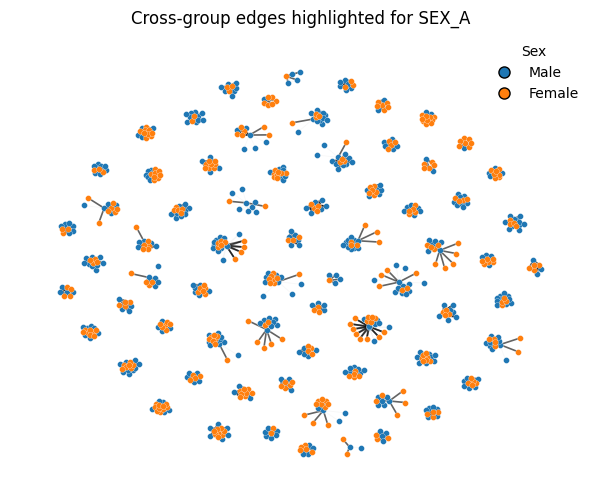

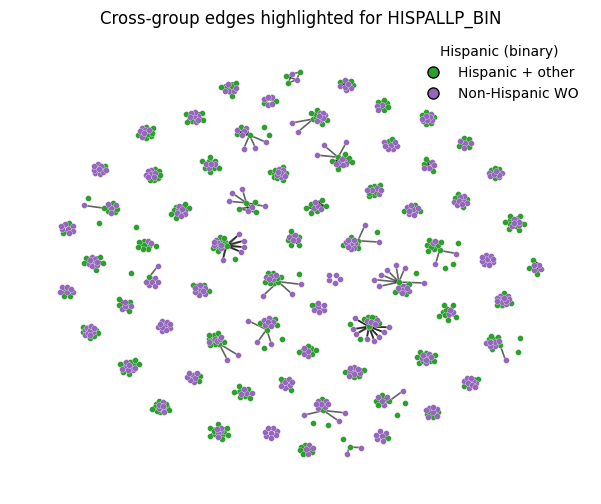

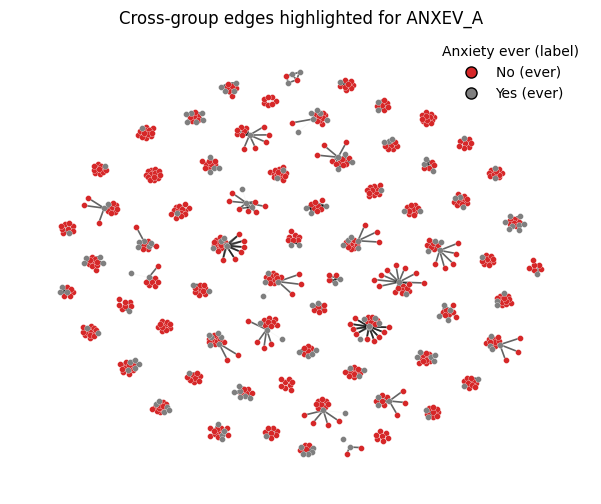

In [29]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, networkx as nx
from scipy.sparse import triu

# share Layout for all graphs
deg = np.asarray(A.sum(axis=1)).ravel()
p = deg / deg.sum() if deg.sum() > 0 else None
rng = np.random.default_rng(0)
k_vis = min(800, n)   # tweak as you like
sample_idx = np.sort(rng.choice(n, size=k_vis, replace=False, p=p))

As = A[sample_idx][:, sample_idx].tocsr()
U = triu(As, k=1).tocoo()     # undirected edges once
eu, ev, ew = U.row, U.col, U.data

G = nx.Graph()
G.add_weighted_edges_from(zip(eu, ev, ew))
pos = nx.spring_layout(G, seed=0, iterations=60)  # fixed layout across plots

# customization of colors and labels
DEFAULT_SEQ = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
               "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]

PALETTES = {
    "SEX_A":        {0:"#1f77b4", 1:"#ff7f0e"},        # blue / orange
    "HISPALLP_BIN": {0:"#2ca02c", 1:"#9467bd"},        # green / purple
    "ANXEV_A":      {0:"#d62728", 1:"#7f7f7f"},        # red / gray
}


READABLE_TITLE = {
    "SEX_A": "Sex",
    "HISPALLP_BIN": "Hispanic (binary)",
    "ANXEV_A": "Anxiety ever (label)",
}


READABLE_LABEL = {
    "SEX_A":        {0: "Male", 1: "Female"},
    "HISPALLP_BIN": {0: "Hispanic + other", 1: "Non-Hispanic WO"},
    "ANXEV_A":      {0: "No (ever)",   1: "Yes (ever)"},
}

def _readable_label_for(attr_col, value):
    m = READABLE_LABEL.get(attr_col, {})
    
    if value in m:
        return m[value]
    try:
        iv = int(value)
        if iv in m:
            return m[iv]
    except Exception:
        pass
    return str(value)


def _exp_same_baseline(vals_u, vals_v, w=None):
    # sum_i p_i^2 over endpoint shares
    endpoints = np.concatenate([vals_u, vals_v])
    if w is None:
        _, codes = np.unique(endpoints, return_inverse=True)
        shares = np.bincount(codes) / codes.size
    else:
        ww = np.concatenate([w, w])
        _, codes = np.unique(endpoints, return_inverse=True)
        shares = np.bincount(codes, weights=ww) / ww.sum()
    return float((shares**2).sum())

def _colors_for_attr(attr_col, vals):
    # map each category to a fixed hex color
    cats = list(np.unique(vals))
    pal = PALETTES.get(attr_col, {})
    colors = []
    for i, c in enumerate(cats):
        colors.append(pal.get(c, DEFAULT_SEQ[i % len(DEFAULT_SEQ)]))
    color_by_cat = dict(zip(cats, colors))
    return cats, color_by_cat

def draw_attr(attr_col, highlight="cross", node_size=18, edge_base="#CCCCCC"):
    # values for sampled nodes
    vals_all = nodes.loc[sample_idx, attr_col].to_numpy()
    cats, color_by_cat = _colors_for_attr(attr_col, vals_all)

    # for edge stats / highlighting
    vals_u = vals_all[eu]
    vals_v = vals_all[ev]
    same = (vals_u == vals_v)
    cross = ~same

    obs_same_unw = float(same.mean()) if same.size else np.nan
    obs_same_w   = float(ew[same].sum()) / float(ew.sum()) if ew.size and ew.sum()>0 else np.nan
    exp_same_unw = _exp_same_baseline(vals_u, vals_v, w=None)
    exp_same_w   = _exp_same_baseline(vals_u, vals_v, w=ew)
    nh_unw = (obs_same_unw - exp_same_unw) / (1 - exp_same_unw) if (1-exp_same_unw)>0 else np.nan

   
    fig, ax = plt.subplots(figsize=(7.5, 6))

    # base edges faint
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=list(zip(eu, ev)), edge_color=edge_base, alpha=0.15, width=0.6)

    # emphasize selected edges
    sel = np.where(cross)[0] if highlight=="cross" else np.where(same)[0]
    edgelist = [(int(eu[i]), int(ev[i])) for i in sel]
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edgelist, edge_color="#000000", alpha=0.6, width=1.2)

    # nodes: draw per category with explicit hex colors
    for cat in cats:
        idx = np.where(vals_all == cat)[0]
        nx.draw_networkx_nodes(
            G, pos, nodelist=idx, node_color=color_by_cat[cat],
            node_size=node_size, linewidths=0.2, edgecolors="white", ax=ax
        )

    # legend using Readable labels
    handles = [plt.Line2D([0],[0], marker='o', color='none',
                          markerfacecolor=color_by_cat[c], markersize=8)
               for c in cats]
    labels  = [_readable_label_for(attr_col, c) for c in cats]
    title   = READABLE_TITLE.get(attr_col, attr_col)
    ax.legend(handles, labels, title=title, loc="best", frameon=False)

    ax.set_axis_off()
    ax.set_title(f"Cross-group edges highlighted for {attr_col}")
    
    plt.show()


# draw three graphs
draw_attr("SEX_A",        highlight="cross", node_size=18)
draw_attr("HISPALLP_BIN", highlight="cross", node_size=18)
draw_attr("ANXEV_A",      highlight="cross", node_size=18)


In [13]:
#Sweep for defining the best alpha and gama for community detection

# assumes A_age (CSR), nodes DataFrame with AGEP_A, SEX_A, HISPALLP_BIN, instance_weight
import numpy as np, pandas as pd
from scipy.sparse import coo_matrix, triu
import igraph as ig, leidenalg as la

def build_weighted(A_age, w_raw, alpha=0.5, eps=0.05):
    w = np.log1p(np.clip(w_raw, 0, None)).astype(float)
    if w.max() > w.min():
        w = (w - w.min()) / (w.max() - w.min())
    w = eps + (1-eps)*w
    C = A_age.tocoo()
    scale = (w[C.row] * w[C.col]) ** (0.5*alpha)
    W = coo_matrix((C.data*scale, (C.row, C.col)), shape=A_age.shape).tocsr()
    return ((W + W.T)*0.5).tocsr()

def r2_age(x, g, w=None):
    x = np.asarray(x, float); g = np.asarray(g)
    if w is None:
        mu = x.mean(); ss_tot = ((x-mu)**2).sum()
        df = pd.DataFrame({"x":x,"g":g}); m = df.groupby("g")["x"].mean(); n = df.groupby("g")["x"].size()
        ss_b = ((m-mu)**2 * n).sum()
    else:
        w = np.asarray(w, float); mu = (x*w).sum()/w.sum()
        ss_tot = (w*(x-mu)**2).sum()
        d = pd.DataFrame({"x":x,"g":g,"w":w})
        wg = d.groupby("g")["w"].sum()
        mg = d.groupby("g", observed=True)[["x","w"]].apply(lambda z: (z["x"]*z["w"]).sum()/z["w"].sum())
        ss_b = ((mg-mu)**2 * wg).sum()
    return float(ss_b/ss_tot) if ss_tot>0 else np.nan

def mi_bits(g, a, w=None, base=2.0):
    g = np.asarray(g); a = np.asarray(a)
    w = np.ones_like(g, float) if w is None else np.asarray(w, float)
    df = pd.DataFrame({"g":g,"a":a,"w":w})
    Pga = df.groupby(["g","a"])["w"].sum(); Z = Pga.sum(); Pga/=Z
    Pg = Pga.groupby(level=0).sum(); Pa = Pga.groupby(level=1).sum()
    mi = 0.0
    for (gi, ai), p in Pga.items():
        if p>0: mi += p * (np.log(p/(Pg[gi]*Pa[ai]))/np.log(base))
    return float(mi)

def leiden_on(W, gamma=0.3, seed=42):
    U = triu(W, 1).tocoo()
    g = ig.Graph(n=W.shape[0], edges=list(zip(U.row.tolist(), U.col.tolist())), directed=False)
    g.es["weight"] = U.data.tolist()
    part = la.find_partition(g, la.RBConfigurationVertexPartition, weights="weight",
                             resolution_parameter=gamma, seed=seed)
    return np.asarray(part.membership, int), float(part.quality())

# sweep a few values (keep short)
for alpha in [0.25, 0.5, 0.75]:
    W = build_weighted(A_age, nodes["instance_weight"].to_numpy(), alpha=alpha, eps=0.05)
    for gamma in [0.2, 0.3, 0.4]:
        comm, Q = leiden_on(W, gamma=gamma)
        r2u = r2_age(nodes["AGEP_A"], comm, None)
        r2w = r2_age(nodes["AGEP_A"], comm, nodes["instance_weight"])
        mi_sex = mi_bits(comm, nodes["SEX_A"])
        mi_his = mi_bits(comm, nodes["HISPALLP_BIN"])
        print(f"alpha={alpha:.2f}, gamma={gamma:.2f} → k={comm.max()+1:4d}, Q={Q:.1f}, R2_age={r2u:.3f}/{r2w:.3f}, "
              f"MI(sex)={mi_sex:.3f}, MI(hisp)={mi_his:.3f}")



alpha=0.25, gamma=0.20 → k=  69, Q=653353.7, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.25, gamma=0.30 → k=  69, Q=652299.1, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.25, gamma=0.40 → k=  69, Q=651244.6, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.50, gamma=0.20 → k=  69, Q=488968.9, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.50, gamma=0.30 → k=  69, Q=488175.8, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.50, gamma=0.40 → k=  69, Q=487382.7, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.75, gamma=0.20 → k=  69, Q=368748.3, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.75, gamma=0.30 → k=  69, Q=368147.4, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034
alpha=0.75, gamma=0.40 → k=  69, Q=367546.5, R2_age=1.000/1.000, MI(sex)=0.004, MI(hisp)=0.034


In [14]:
# === Leiden on age graph reweighted by instance_weight (no heads, fixed joins) ===
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import load_npz, coo_matrix, triu
import igraph as ig
import leidenalg as la

# -------- paths --------
ADJ_PATH   = Path("A_graph_age_rbf.npz")          # age-only RBF similarity (unpruned)
NODES_PATH = Path("age_weight_pruned_nodes.csv")  # aligned to adjacency row order

# -------- params --------
GAMMA = 0.3   # lower => fewer/larger communities; higher => more/smaller
SEED  = 42
ALPHA = 0.5   # weight influence on edges; 0=ignore instance_weight

# -------- load --------
A_age = load_npz(ADJ_PATH).tocsr()
nodes = pd.read_csv(NODES_PATH).copy()
if "node_id" in nodes.columns:
    nodes = nodes.sort_values("node_id").reset_index(drop=True)
assert A_age.shape[0] == len(nodes), f"Row mismatch: A has {A_age.shape[0]}, nodes has {len(nodes)}."

# clean types
for c in ["ANXEV_A","SEX_A","HISPALLP_BIN"]:
    if c in nodes.columns:
        nodes[c] = pd.to_numeric(nodes[c], errors="coerce").fillna(0).astype(int)
nodes["AGEP_A"] = pd.to_numeric(nodes["AGEP_A"], errors="coerce")
nodes["instance_weight"] = pd.to_numeric(nodes["instance_weight"], errors="coerce").fillna(0.0)

# -------- reweight edges by instance_weight (no pruning) --------
alpha = 0.5               # soften weight influence
w = np.log1p(nodes["instance_weight"].clip(lower=0).to_numpy(np.float64))
w = (w - w.min()) / (w.max() - w.min() + 1e-12)
eps = 0.05
w = eps + (1 - eps) * w   # floor at 0.05

C = A_age.tocoo()
scale = (w[C.row] * w[C.col]) ** (0.5 * alpha)
A_weighted = coo_matrix((C.data * scale, (C.row, C.col)), shape=A_age.shape).tocsr()
A_weighted = ((A_weighted + A_weighted.T) * 0.5).tocsr()

# -------- build igraph (one undirected edge per pair with weight) --------
U = triu(A_weighted, k=1).tocoo()
g = ig.Graph(n=A_weighted.shape[0], edges=list(zip(U.row.tolist(), U.col.tolist())), directed=False)
g.es["weight"] = U.data.tolist()

# -------- Leiden (RB Configuration) --------
part = la.find_partition(
    g, la.RBConfigurationVertexPartition,
    weights="weight",
    resolution_parameter=GAMMA,
    seed=SEED
)
membership = np.asarray(part.membership, dtype=int)
quality = float(part.quality())
n_comm = int(membership.max() + 1)
print(f"Leiden: {n_comm} communities (gamma={GAMMA}), quality={quality:.4f}")

nodes["community"] = membership

# -------- helpers (weighted stats, variance explained, MI) --------
def wmean(x, w):
    x, w = np.asarray(x, float), np.asarray(w, float)
    s = w.sum()
    return (x*w).sum()/s if s > 0 else np.nan

def wvar(x, w):
    x, w = np.asarray(x, float), np.asarray(w, float)
    s = w.sum()
    if s <= 0: return np.nan
    mu = (x*w).sum()/s
    return (w*((x-mu)**2)).sum()/s

def variance_explained_by_groups(x, grp, w=None):
    x = np.asarray(x, float); g = np.asarray(grp)
    if w is None:
        mu = np.nanmean(x); ss_tot = np.nansum((x-mu)**2)
        df = pd.DataFrame({"x": x, "g": g})
        means = df.groupby("g", observed=True)["x"].mean()
        sizes = df.groupby("g", observed=True)["x"].size()
        ss_between = ((means - mu)**2 * sizes).sum()
    else:
        w = np.asarray(w, float)
        mu = wmean(x, w); ss_tot = wvar(x, w) * w.sum()
        d = pd.DataFrame({"x": x, "g": g, "w": w})
        wg = d.groupby("g", observed=True)["w"].sum()
        mg = d.groupby("g", observed=True)[["x","w"]].apply(lambda z: wmean(z["x"], z["w"]))
        ss_between = ((mg - mu)**2 * wg).sum()
    return float(ss_between / ss_tot) if ss_tot > 0 else np.nan

def mutual_information(group, attr, weights=None, base=2.0):
    g = np.asarray(group); a = np.asarray(attr)
    w = np.ones_like(g, float) if weights is None else np.asarray(weights, float)
    df = pd.DataFrame({"g": g, "a": a, "w": w})
    Pga = df.groupby(["g","a"], observed=True)["w"].sum()
    Z = Pga.sum(); Pga = Pga / Z
    Pg = Pga.groupby(level=0).sum(); Pa = Pga.groupby(level=1).sum()
    mi = 0.0
    for (gi, ai), p in Pga.items():
        if p > 0:
            mi += p * (np.log(p / (Pg[gi]*Pa[ai])) / np.log(base))
    return float(mi)

# -------- summaries (no .head prints) --------
summary = (nodes.groupby("community", observed=True)
           .agg(size=("community","size"),
                age_mean=("AGEP_A","mean"),
                age_std=("AGEP_A","std"),
                pos_rate_unw=("ANXEV_A","mean"),
                weight_sum=("instance_weight","sum")))

# weighted age & outcome — use column subset to avoid FutureWarning
age_w = (nodes.groupby("community", observed=True)[["AGEP_A","ANXEV_A","instance_weight"]]
         .apply(lambda d: pd.Series({
             "age_mean_w": wmean(d["AGEP_A"], d["instance_weight"]),
             "age_std_w":  np.sqrt(wvar(d["AGEP_A"], d["instance_weight"])) if d["instance_weight"].sum()>0 else np.nan,
             "pos_rate_w": wmean(d["ANXEV_A"], d["instance_weight"])
         })))

summary = summary.join(age_w, how="left")

def comp_props(df, col, wcol, name_map=None):
    # unweighted proportions
    cu = (df.pivot_table(index="community", columns=col, values="AGEP_A",
                         aggfunc="count", fill_value=0, observed=True).astype(float))
    cu = cu.div(cu.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    # weighted proportions
    cw = (df.pivot_table(index="community", columns=col, values=wcol,
                         aggfunc="sum", fill_value=0.0, observed=True).astype(float))
    cw = cw.div(cw.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    # rename columns to readable, unique names to avoid overlaps
    if name_map is None:
        map_u = {k: f"p_{col}_{k}" for k in cu.columns}
        map_w = {k: f"p_{col}_{k}_w" for k in cw.columns}
    else:
        map_u = {k: name_map.get(k, f"p_{col}_{k}") for k in cu.columns}
        map_w = {k: (name_map.get(k, f"p_{col}_{k}") + "_w") for k in cw.columns}
    return cu.rename(columns=map_u), cw.rename(columns=map_w)

# compositions with readable names (prevents '0'/'1' overlaps)
if "SEX_A" in nodes.columns:
    sex_map = {0:"p_male", 1:"p_female"}
    su, sw = comp_props(nodes, "SEX_A", "instance_weight", sex_map)
    summary = summary.join(su, how="left").join(sw, how="left")

if "HISPALLP_BIN" in nodes.columns:
    hisp_map = {0:"p_hisp_plus_others", 1:"p_non_hisp_white"}
    hu, hw = comp_props(nodes, "HISPALLP_BIN", "instance_weight", hisp_map)
    summary = summary.join(hu, how="left").join(hw, how="left")

# save files (no heads)
summary.sort_values("size", ascending=False).to_csv("age_weight_leiden_summary.csv")
nodes[["node_id","community"] if "node_id" in nodes.columns else ["community"]].to_csv(
    "age_weight_leiden_membership.csv", index=False
)

print("Saved: age_weight_leiden_summary.csv, age_weight_leiden_membership.csv")

# -------- interpretable diagnostics (what forms communities?) --------
R2_age_unw = variance_explained_by_groups(nodes["AGEP_A"], nodes["community"], w=None)
R2_age_w   = variance_explained_by_groups(nodes["AGEP_A"], nodes["community"], w=nodes["instance_weight"])
print(f"Age variance explained by community: R^2_unw={R2_age_unw:.3f}, R^2_w={R2_age_w:.3f}")

mi_sex_unw = mutual_information(nodes["community"], nodes["SEX_A"]) if "SEX_A" in nodes.columns else np.nan
mi_his_unw = mutual_information(nodes["community"], nodes["HISPALLP_BIN"]) if "HISPALLP_BIN" in nodes.columns else np.nan
mi_lbl_unw = mutual_information(nodes["community"], nodes["ANXEV_A"])
mi_sex_w   = mutual_information(nodes["community"], nodes["SEX_A"], nodes["instance_weight"]) if "SEX_A" in nodes.columns else np.nan
mi_his_w   = mutual_information(nodes["community"], nodes["HISPALLP_BIN"], nodes["instance_weight"]) if "HISPALLP_BIN" in nodes.columns else np.nan
mi_lbl_w   = mutual_information(nodes["community"], nodes["ANXEV_A"], nodes["instance_weight"])

print(f"MI (bits) — SEX_A: unw={mi_sex_unw:.3f}, w={mi_sex_w:.3f}; "
      f"HISPALLP_BIN: unw={mi_his_unw:.3f}, w={mi_his_w:.3f}; "
      f"ANXEV_A: unw={mi_lbl_unw:.3f}, w={mi_lbl_w:.3f}")



Leiden: 69 communities (gamma=0.3), quality=488175.8021
Saved: age_weight_leiden_summary.csv, age_weight_leiden_membership.csv
Age variance explained by community: R^2_unw=1.000, R^2_w=1.000
MI (bits) — SEX_A: unw=0.004, w=0.005; HISPALLP_BIN: unw=0.034, w=0.037; ANXEV_A: unw=0.010, w=0.012


In [6]:
# Within-community age dispersion
age_std_by_comm = nodes.groupby("community")["AGEP_A"].std().fillna(0)
print("Median within-community age std:", age_std_by_comm.median())
print("Share of communities with std <= 1 year:", (age_std_by_comm <= 1).mean())

# Community size distribution
sizes = nodes["community"].value_counts().sort_values(ascending=False)
print("Median community size:", int(sizes.median()))
print("Communities with size <= 5:", int((sizes <= 5).sum()))


Median within-community age std: 0.0
Share of communities with std <= 1 year: 1.0
Median community size: 440
Communities with size <= 5: 0


In [19]:
# === Homophily summary (SEX_A, HISPALLP_BIN, ANXEV_A) in printed format ===
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import load_npz, csr_matrix, triu

# load adjacency (prefer what you just used)
def get_adj():
    try:
        return A_weighted.copy().tocsr()
    except NameError:
        pass
    if Path("age_weight_pruned_adjacency.npz").exists():
        return load_npz("age_weight_pruned_adjacency.npz").tocsr()
    return load_npz("A_graph_age_rbf.npz").tocsr()

A = get_adj().astype(np.float64).tocsr()
A.setdiag(0.0); A.eliminate_zeros()
A = ((A + A.T) * 0.5).tocsr()  # ensure symmetry

# one undirected edge per pair
U = triu(A, k=1).tocoo()
eu, ev, ew = U.row, U.col, U.data

# ---- load node attributes ----
nodes = pd.read_csv("age_weight_pruned_nodes.csv")
if "node_id" in nodes.columns:
    nodes = nodes.sort_values("node_id").reset_index(drop=True)

# coerce binaries to {0,1}
for c in ["SEX_A", "HISPALLP_BIN", "ANXEV_A"]:
    if c in nodes.columns:
        nodes[c] = pd.to_numeric(nodes[c], errors="coerce").fillna(0).astype(int)

# ---- helpers ----
def weighted_homophily_from_edges(u, v, w, group01):
    same = (group01[u] == group01[v])
    num = float(w[same].sum())
    den = float(w.sum()) + 1e-12
    return num / den

def expected_same_endpoint_baseline(u, v, w, group01):
    # random mixing over edge endpoints (unweighted by default here)
    endpoints = np.concatenate([group01[u], group01[v]])
    counts = np.bincount(endpoints, minlength=2).astype(float)
    p = counts / counts.sum()
    return float((p**2).sum())

def mean_degree_per_group(A_csr: csr_matrix, group01):
    deg = np.asarray(A_csr.sum(1)).ravel()
    d0 = float(deg[group01 == 0].mean()) if (group01 == 0).any() else np.nan
    d1 = float(deg[group01 == 1].mean()) if (group01 == 1).any() else np.nan
    return d0, d1

def neighbor_same_group_exposure(A_csr: csr_matrix, group01):
    deg = (np.asarray(A_csr.sum(1)).ravel() + 1e-12)
    frac1 = np.asarray(A_csr.dot(group01)) / deg  # share of incident weight to group==1
    same = np.where(group01 == 1, frac1, 1.0 - frac1)
    e0 = float(same[group01 == 0].mean()) if (group01 == 0).any() else np.nan
    e1 = float(same[group01 == 1].mean()) if (group01 == 1).any() else np.nan
    return e0, e1

def print_structural_summary(name, group01, labels):
    h_obs = weighted_homophily_from_edges(eu, ev, ew, group01)
    h_exp = expected_same_endpoint_baseline(eu, ev, ew, group01)
    d0, d1 = mean_degree_per_group(A, group01)
    e0, e1 = neighbor_same_group_exposure(A, group01)
    print(f"{name}: homophily obs={h_obs:.3f} exp={h_exp:.3f} Δ={h_obs - h_exp:+.3f}")
    print(f"  mean degree: {labels[0]}={d0:.2f}, {labels[1]}={d1:.2f}")
    print(f"  same-group exposure: {labels[0]}={e0:.3f}, {labels[1]}={e1:.3f}")

# ---- run summaries ----
if {"SEX_A","HISPALLP_BIN","ANXEV_A"}.issubset(nodes.columns):
    g_sex  = nodes["SEX_A"].to_numpy(int)              # 0=Male, 1=Female
    g_hisp = nodes["HISPALLP_BIN"].to_numpy(int)       # 0=Hisp+Others, 1=Non-Hisp White
    g_lbl  = nodes["ANXEV_A"].to_numpy(int)            # 0=No, 1=Yes

    print_structural_summary("SEX",  g_sex,  {0:"Male", 1:"Female"})
    print_structural_summary("HISP", g_hisp, {0:"Hisp+Others", 1:"Non-Hisp White"})
    print_structural_summary("ANXEV_A", g_lbl, {0:"No", 1:"Yes"})
else:
    missing = {"SEX_A","HISPALLP_BIN","ANXEV_A"} - set(nodes.columns)
    raise ValueError(f"Missing required columns in nodes CSV: {missing}")


SEX: homophily obs=0.504 exp=0.503 Δ=+0.001
  mean degree: Male=16.95, Female=16.40
  same-group exposure: Male=0.467, Female=0.534
HISP: homophily obs=0.568 exp=0.550 Δ=+0.019
  mean degree: Hisp+Others=16.85, Non-Hisp White=16.55
  same-group exposure: Hisp+Others=0.376, Non-Hisp White=0.666
ANXEV_A: homophily obs=0.740 exp=0.703 Δ=+0.037
  mean degree: No=17.24, Yes=14.04
  same-group exposure: No=0.846, Yes=0.164


In [ ]:
#Code sources

#https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
#https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.kneighbors_graph.html
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csgraph.connected_components.html
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.rbf_kernel.html
#https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.RBF.html
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.save_npz.html
#https://leidenalg.readthedocs.io/en/stable/intro.html
#https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/
#https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn
#https://www.youtube.com/watch?v=Nz73vXn5afE
#https://www.youtube.com/watch?v=9-sIgMrMPuY
#https://youtu.be/gGdlYicGIIo?si=tElphyYBEvXdA0Tx
#https://www.geeksforgeeks.org/machine-learning/radial-basis-function-kernel-machine-learning/
#https://machinelearningmastery.com/normalize-standardize-time-series-data-python/
#https://www.youtube.com/watch?v=94f_bId5HGI
#https://machinelearningmastery.com/tutorial-to-implement-k-nearest-neighbors-in-python-from-scratch/
#https://www.w3schools.com/python/python_ml_knn.asp
#https://towardsdatascience.com/k-nearest-neighbor-classifier-explained-a-visual-guide-with-code-examples-for-beginners-a3d85cad00e1/
#https://medium.com/analytics-vidhya/implementing-k-nearest-neighbours-knn-without-using-scikit-learn-3905b4decc3c
#https://medium.com/@swapnil.agashe456/leiden-clustering-for-community-detection-a-step-by-step-guide-with-python-implementation-c883933a1430
#https://github.com/CWTSLeiden/networkanalysis
#https://github.com/vtraag/leidenalg



